# Exploratory Data Analysis — NSL-KDD (70/15/15)
**Network Intrusion Detection Dataset**

This notebook explores the NSL-KDD dataset before modeling. The goal of EDA is to
*understand* the data — its structure, quality, class balance, and any distribution
issues — so that preprocessing and modeling choices are justified rather than arbitrary.

**What we are checking:**
1. Structure & integrity (shape, missing values, duplicates)
2. Dead / low-variance features
3. Target distribution & class imbalance
4. Train vs test distribution shift (the defining property of NSL-KDD)
5. Feature skew
6. Feature correlation & redundancy
7. Categorical features


## Setup
Load the three splits and attach a 5-class attack-family label.

In [ ]:
import zipfile, pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")

zipfile.ZipFile("NSL_KDD_70_15_15_Dataset.zip").extractall("data")

CATS = ["protocol_type", "service", "flag"]

# Map each attack label to one of 5 families (standard NSL-KDD grouping)
FAMILY = {"normal":"normal",
 "neptune":"dos","back":"dos","land":"dos","pod":"dos","smurf":"dos","teardrop":"dos",
 "mailbomb":"dos","apache2":"dos","processtable":"dos","udpstorm":"dos","worm":"dos",
 "ipsweep":"probe","nmap":"probe","portsweep":"probe","satan":"probe","mscan":"probe","saint":"probe",
 "ftp_write":"r2l","guess_passwd":"r2l","imap":"r2l","multihop":"r2l","phf":"r2l","spy":"r2l",
 "warezclient":"r2l","warezmaster":"r2l","sendmail":"r2l","named":"r2l","snmpgetattack":"r2l",
 "snmpguess":"r2l","xlock":"r2l","xsnoop":"r2l","httptunnel":"r2l",
 "buffer_overflow":"u2r","loadmodule":"u2r","perl":"u2r","rootkit":"u2r","ps":"u2r",
 "sqlattack":"u2r","xterm":"u2r"}

def load(path):
    d = pd.read_csv(path)
    d["binary"] = np.where(d.label == "normal", "normal", "attack")
    d["family"] = d.label.map(FAMILY).fillna("unknown")
    return d

tr = load("data/KDD_train_70.csv")
va = load("data/KDD_val_15.csv")
te = load("data/KDD_test_15.csv")
splits = {"train": tr, "val": va, "test": te}
print("Loaded:", {n: d.shape for n, d in splits.items()})

Loaded: {'train': (103801, 44), 'val': (22172, 44), 'test': (22544, 44)}


## 1. Structure & Integrity
First check the basics: how big is each split, are there missing values, are there
duplicate rows? These decide whether any cleaning is needed before analysis.

In [ ]:
for n, d in splits.items():
    print(f"{n:6s} shape={d.shape}  nulls={d.isna().sum().sum()}  dups={d.duplicated().sum()}")

feats = [c for c in tr.columns if c not in ("label", "binary", "family")]
print(f"\n{len(feats)} features  |  dtypes:", tr[feats].dtypes.value_counts().to_dict())

train  shape=(103801, 44)  nulls=0  dups=0
val    shape=(22172, 44)  nulls=0  dups=0
test   shape=(22544, 44)  nulls=0  dups=0

41 features  |  dtypes: {dtype('int64'): 23, dtype('float64'): 15, <StringDtype(storage='python', na_value=nan)>: 3}


**Finding:** The dataset is completely clean — **0 missing values** and **0 duplicate rows**
in every split. No imputation or deduplication is required. There are 41 features
(38 numeric + 3 categorical) plus the label.

## 2. Dead & Low-Variance Features
A feature with only one value carries no information and can break scaling
(division by zero standard deviation). We flag constant and near-constant columns.

In [ ]:
constant = [c for c in feats if tr[c].nunique() == 1]
near = [c for c in feats if tr[c].value_counts(normalize=True).iloc[0] > 0.995]
print("Constant   :", constant)
print("Near-constant (>99.5% one value):", near)

Constant   : ['num_outbound_cmds']
Near-constant (>99.5% one value): ['land', 'urgent', 'num_failed_logins', 'root_shell', 'su_attempted', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login']


**Finding:** `num_outbound_cmds` is **constant** (all zeros) — it will be dropped in
preprocessing. Nine further columns are near-constant; they add little signal but
don't need to be removed for tree-based models.

## 3. Target Distribution & Class Imbalance
We model at the 5-family level (normal / dos / probe / r2l / u2r). How balanced
are these classes? Severe imbalance will hurt recall on the rare attack types.

In [ ]:
dist = pd.DataFrame({n: d.family.value_counts() for n, d in splits.items()}).fillna(0).astype(int)
print(dist)
print("\nTrain class ratio (largest : smallest) =",
      int(dist["train"].max() / dist["train"].min()), ": 1")

        train    val  test
family                    
dos     37890   8037  7460
normal  55490  11853  9711
probe    9574   2082  2421
r2l       801    194  2885
u2r        46      6    67

Train class ratio (largest : smallest) = 1206 : 1


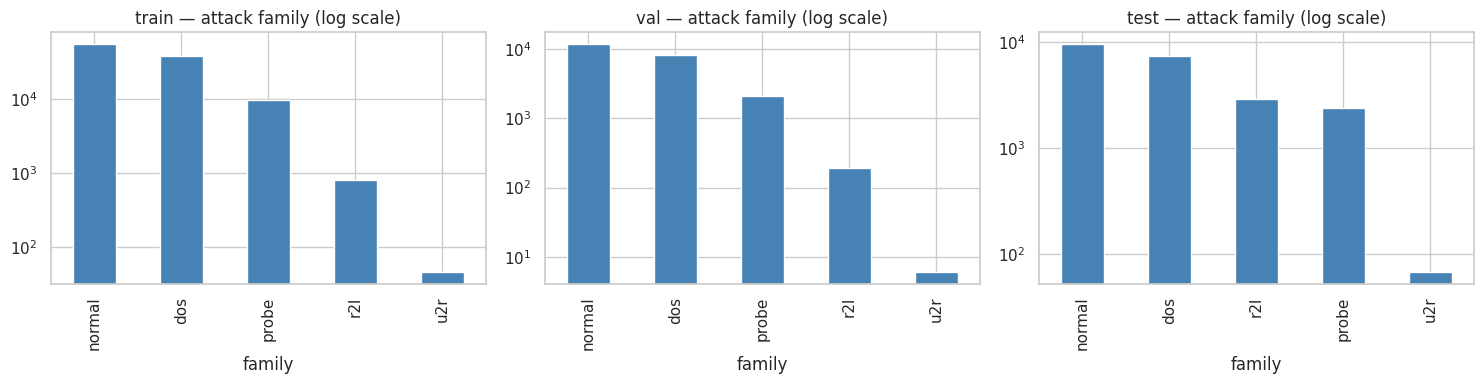

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, (n, d) in zip(ax, splits.items()):
    d.family.value_counts().plot(kind="bar", ax=a, color="steelblue")
    a.set_title(f"{n} — attack family (log scale)"); a.set_yscale("log")
plt.tight_layout(); plt.show()

**Finding:** Severe class imbalance. In training, **normal has 55,490 rows but u2r has
only 46** — a ratio over 1000:1. This is why r2l and u2r will need class weighting or
oversampling (applied to the *training set only*) during modeling. Note also that
**r2l grows from 801 rows in train to 2,885 in test** — a clue to the next finding.

## 4. Train vs Test Distribution Shift
This is the defining property of NSL-KDD: the test set deliberately contains attack
types **never seen in training**. This makes the benchmark a test of *generalization*,
not memorization — and explains any gap between validation and test scores.

In [ ]:
unseen = sorted(set(te.label) - set(tr.label))
print(f"Attack types in test but NOT in train: {len(unseen)}")
print(unseen)
print(f"\nShare of test rows from unseen attacks: {te.label.isin(unseen).mean():.2%}")
print(f"Normal rate  train={tr.binary.eq('normal').mean():.3f}  "
      f"test={te.binary.eq('normal').mean():.3f}")

Attack types in test but NOT in train: 17
['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']

Share of test rows from unseen attacks: 16.63%
Normal rate  train=0.535  test=0.431


**Finding:** **17 attack types appear in test that are absent from training**, making up
**16.6% of all test rows**. The normal-traffic rate also shifts (0.535 → 0.431). A model
will score highly on the same-distribution validation set but drop sharply on test —
this gap is expected and is the core challenge of the dataset, not a modeling error.

## 5. Feature Skew
Many network features (byte counts, connection counts) are extremely right-skewed.
Skewed features distort distance-based and gradient-based models, so we identify
which need a log transform.

In [ ]:
num = [c for c in feats if c not in CATS]
skew = tr[num].skew().sort_values(ascending=False)
print("Top 10 most skewed features:\n")
print(skew.head(10).round(1))

Top 10 most skewed features:

is_host_login         322.2
dst_bytes             263.3
num_compromised       239.4
num_root              229.5
src_bytes             209.2
urgent                141.8
land                   72.0
num_file_creations     59.4
num_shells             56.5
num_failed_logins      49.4
dtype: float64


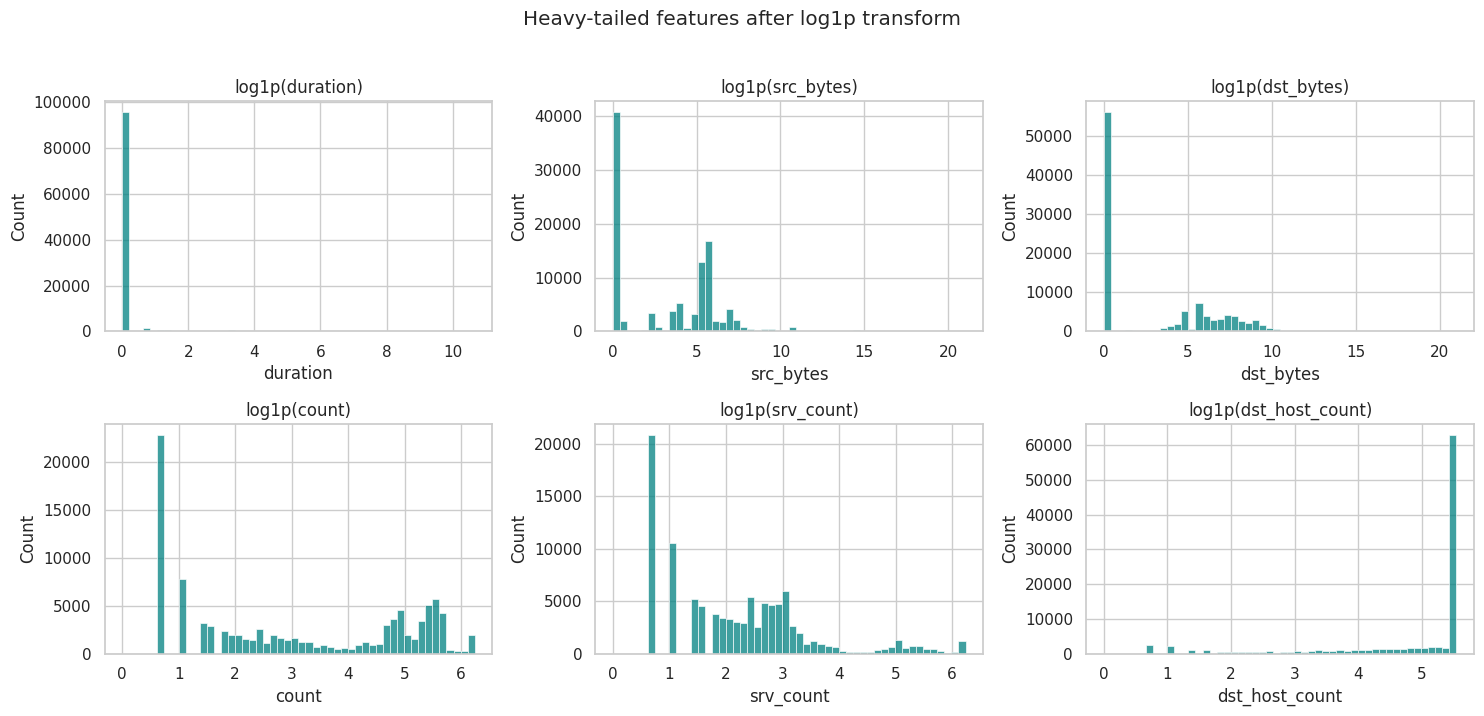

In [ ]:
heavy = ["duration", "src_bytes", "dst_bytes", "count", "srv_count", "dst_host_count"]
fig, ax = plt.subplots(2, 3, figsize=(15, 7))
for a, c in zip(ax.ravel(), heavy):
    sns.histplot(np.log1p(tr[c]), bins=50, ax=a, color="teal")
    a.set_title(f"log1p({c})")
plt.suptitle("Heavy-tailed features after log1p transform", y=1.02)
plt.tight_layout(); plt.show()

**Finding:** `dst_bytes` and `src_bytes` have skew above 200 — raw values span 0 to
~1.4 billion. A `log1p` transform (shown above) makes these distributions usable.
This justifies the log-transform step in preprocessing.

## 6. Feature Correlation & Redundancy
Highly correlated features carry duplicate information. Identifying them helps decide
whether dimensionality reduction is worthwhile and aids interpretability.

In [ ]:
corr = tr[num].corr(numeric_only=True)
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pairs = (upper.stack().rename("r").reset_index()
         .query("abs(r) > 0.9").sort_values("r", key=abs, ascending=False))
pairs.columns = ["feature_1", "feature_2", "correlation"]
print(f"{len(pairs)} feature pairs with |correlation| > 0.9:\n")
print(pairs.to_string(index=False))

13 feature pairs with |correlation| > 0.9:

           feature_1                feature_2  correlation
     num_compromised                 num_root     0.999153
         serror_rate          srv_serror_rate     0.993491
         rerror_rate          srv_rerror_rate     0.989558
     srv_serror_rate dst_host_srv_serror_rate     0.986270
dst_host_serror_rate dst_host_srv_serror_rate     0.985169
         serror_rate dst_host_srv_serror_rate     0.981147
         serror_rate     dst_host_serror_rate     0.979405
     srv_serror_rate     dst_host_serror_rate     0.977873
     srv_rerror_rate dst_host_srv_rerror_rate     0.970702
         rerror_rate dst_host_srv_rerror_rate     0.965103
         rerror_rate     dst_host_rerror_rate     0.926907
dst_host_rerror_rate dst_host_srv_rerror_rate     0.924766
     srv_rerror_rate     dst_host_rerror_rate     0.918631


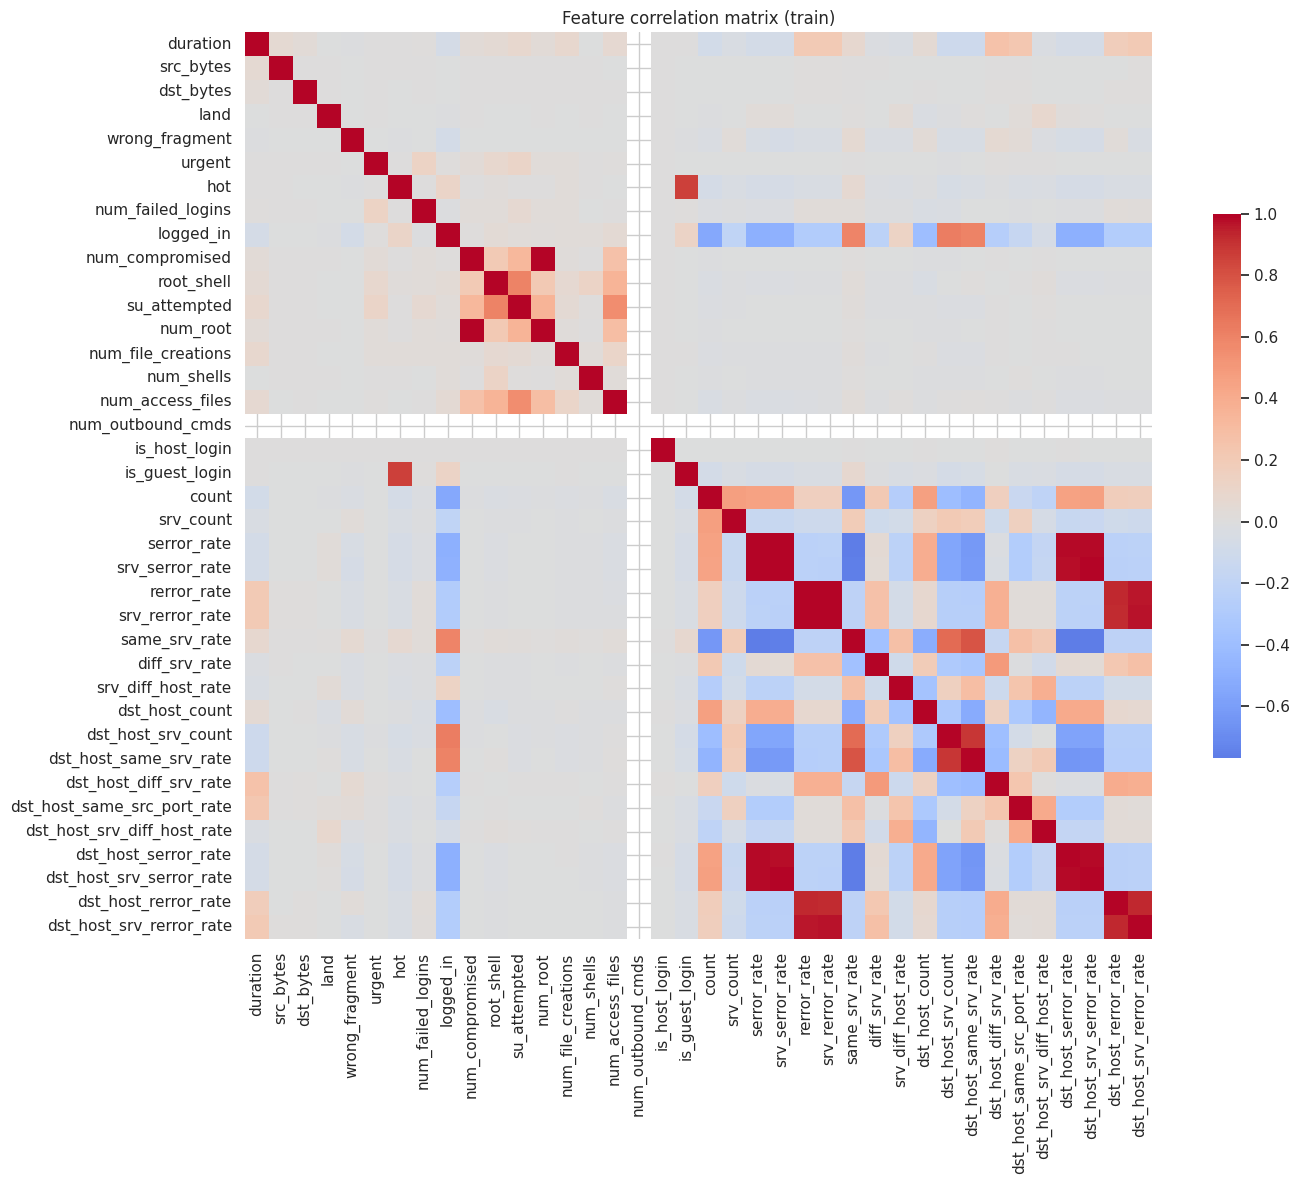

In [ ]:
plt.figure(figsize=(15, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            xticklabels=True, yticklabels=True, cbar_kws={"shrink": 0.6})
plt.title("Feature correlation matrix (train)")
plt.tight_layout(); plt.show()

**Finding:** **13 feature pairs** are highly correlated (|r| > 0.9). The strongest,
`num_root` / `num_compromised` at **0.999**, are effectively the same column. The
serror/rerror rate features form a redundant cluster. For linear models or neural
networks one feature per pair could be dropped; tree ensembles handle this natively.

## 7. Categorical Features
Three features are categorical. We check their cardinality and — importantly — whether
the test set contains any category values missing from train, which would break naive
one-hot encoding.

In [ ]:
for c in CATS:
    unseen_cat = sorted(set(te[c]) - set(tr[c]))
    print(f"{c:14s} cardinality train/val/test = {tr[c].nunique()}/{va[c].nunique()}/{te[c].nunique()}"
          f"  |  unseen in test: {unseen_cat or 'none'}")

protocol_type  cardinality train/val/test = 3/3/3  |  unseen in test: none
service        cardinality train/val/test = 69/66/64  |  unseen in test: none
flag           cardinality train/val/test = 11/11/11  |  unseen in test: none


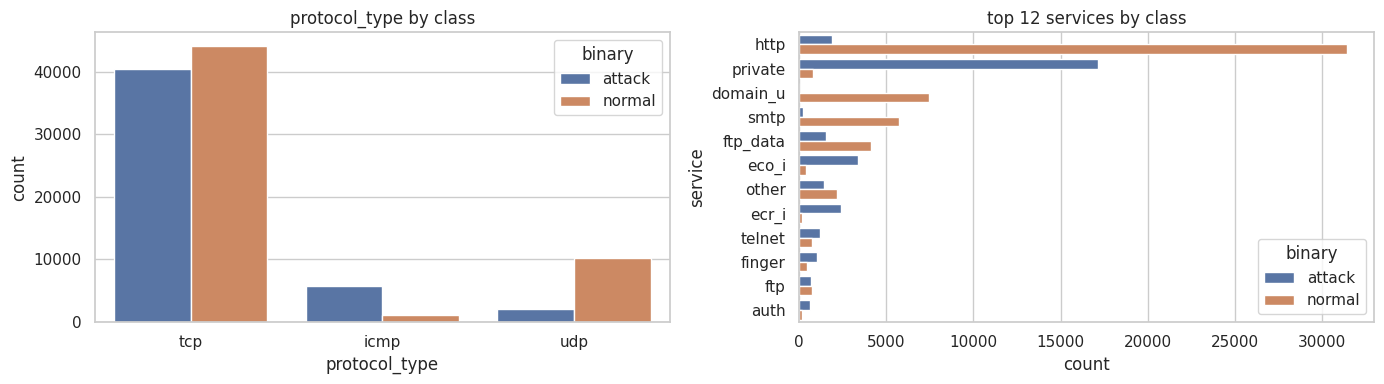

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(data=tr, x="protocol_type", hue="binary", ax=ax[0])
ax[0].set_title("protocol_type by class")
top = tr.service.value_counts().head(12).index
sns.countplot(data=tr[tr.service.isin(top)], y="service", hue="binary", order=top, ax=ax[1])
ax[1].set_title("top 12 services by class")
plt.tight_layout(); plt.show()

**Finding:** `service` has the highest cardinality (69 values) but every test category
also appears in train, so one-hot encoding fitted on the training vocabulary will
align cleanly across splits. `protocol_type` and `flag` are low-cardinality and safe.

## Summary of EDA Findings

| Area | Finding | Implication |
|------|---------|-------------|
| Integrity | 0 nulls, 0 duplicates | No cleaning needed |
| Dead features | `num_outbound_cmds` constant + 9 near-constant | Drop constant column |
| Class balance | u2r = 46 vs normal = 55,490 (>1000:1) | Class weights / SMOTE on train only |
| Distribution shift | 17 unseen attacks = 16.6% of test | Expect val≫test gap; report test score |
| Skew | src_bytes ~209, dst_bytes ~263 | Apply log1p |
| Redundancy | 13 pairs \|r\|>0.9 (num_root/num_compromised = 0.999) | Optional feature reduction |
| Categoricals | service = 69 levels, all seen in test | One-hot fit on train |

**Conclusion:** The data is clean but structurally challenging. The two defining
issues — severe class imbalance and a deliberate train/test distribution shift —
must be handled in preprocessing and acknowledged when interpreting model results.
These observations directly justify the preprocessing pipeline (drop constant column,
log1p transform, one-hot encode, scale, balance training classes) applied in the
next stage.
